In [8]:
from transformers import pipeline
sentiment_classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use cpu


In [9]:
sentiment_classifier = pipeline(
    task="sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    revision="714eb0f"
)
sentiment_classifier("I'm so excited to be learning about large language models")

Device set to use cpu


KeyboardInterrupt: 

In [ ]:
from utils import get_hugging_model_size
get_hugging_model_size(model="distilbert/distilbert-base-uncased-finetuned-sst-2-english", revision="714eb0f")
get_hugging_model_size(model="dslim/bert-base-NER")

Total download size: 1278.59 MB
Total download size: 2063.12 MB


In [ ]:
ner = pipeline("ner", model="dslim/bert-base-NER")
ner("Her name is Anna and she works in New York City for Morgan Stanley")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


[{'entity': 'B-PER',
  'score': 0.9954881,
  'index': 4,
  'word': 'Anna',
  'start': 12,
  'end': 16},
 {'entity': 'B-LOC',
  'score': 0.99960667,
  'index': 9,
  'word': 'New',
  'start': 34,
  'end': 37},
 {'entity': 'I-LOC',
  'score': 0.9993955,
  'index': 10,
  'word': 'York',
  'start': 38,
  'end': 42},
 {'entity': 'I-LOC',
  'score': 0.9995803,
  'index': 11,
  'word': 'City',
  'start': 43,
  'end': 47},
 {'entity': 'B-ORG',
  'score': 0.9957462,
  'index': 13,
  'word': 'Morgan',
  'start': 52,
  'end': 58},
 {'entity': 'I-ORG',
  'score': 0.9979346,
  'index': 14,
  'word': 'Stanley',
  'start': 59,
  'end': 66}]

In [ ]:
get_hugging_model_size("facebook/bart-large-mnli")

Total download size: 6611.17 MB


In [ ]:
# Zero shot classifiers don't require extra training as they are already trained. They are usually larger.

zeroshot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
seq_to_classify = "One day I'd see the world."
labels = ["travel", "cooking", "dancing"]
zeroshot_classifier(seq_to_classify, labels)

# Prints out labels and scores (travel: 0.993, dancing: 0.003, cooking: 0.002)
# Not running because it's actually large to download (1.63GB)

Device set to use cpu


KeyboardInterrupt: 

### Pre-trained Tokenizers

In [ ]:
from transformers import AutoTokenizer
model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
sentence = "I'm so excited to be learning about large language models"
input_ids = tokenizer(sentence)
print(input_ids)
tokens = tokenizer.tokenize(sentence)
print(tokens)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
print(token_ids)
decoded_ids = tokenizer.decode(token_ids)
print(decoded_ids)
print(tokenizer.decode(input_ids.data['input_ids']))
print(tokenizer.decode([101, 102]))

{'input_ids': [101, 1045, 1005, 1049, 2061, 7568, 2000, 2022, 4083, 2055, 2312, 2653, 4275, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['i', "'", 'm', 'so', 'excited', 'to', 'be', 'learning', 'about', 'large', 'language', 'models']
[1045, 1005, 1049, 2061, 7568, 2000, 2022, 4083, 2055, 2312, 2653, 4275]
i ' m so excited to be learning about large language models
[CLS] i ' m so excited to be learning about large language models [SEP]
[CLS] [SEP]


### HuggingFace and PyTorch/TensorFlow

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

In [ ]:
sentence = "I'm so excited to be learning about large language models"
input_ids_pt = tokenizer(sentence, return_tensors="pt")
print(input_ids_pt)

{'input_ids': tensor([[ 101, 1045, 1005, 1049, 2061, 7568, 2000, 2022, 4083, 2055, 2312, 2653,
         4275,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
with torch.no_grad():
    logits = model(**input_ids_pt).logits

predicted_class_id = logits.argmax().item() # Predicted class id is now 1
model.config.id2label[predicted_class_id]

'POSITIVE'

### Saving and Loading models

In [ ]:
model_directory = "saved_models"
tokenizer.save_pretrained(model_directory)

('saved_models/tokenizer_config.json',
 'saved_models/special_tokens_map.json',
 'saved_models/vocab.txt',
 'saved_models/added_tokens.json',
 'saved_models/tokenizer.json')

In [ ]:
model.save_pretrained(model_directory)

### BERT (Hopefully, transformer still works)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForQuestionAnswering
import torch
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

In [3]:
model = BertForQuestionAnswering.from_pretrained(model_name) # 1.4GB
tokenizer = BertTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [4]:
question = "When was the first DVD player released?"
answer_text = "The first DVD player was released in Japan on November 1, 1996. The movie Twister was the first film to be commercially released on DVD in the United States on March 24, 1997."
encoding = tokenizer.encode_plus(question, answer_text)
input_ids = encoding["input_ids"]
sentence_embedding = encoding["token_type_ids"]
tokens = tokenizer.convert_ids_to_tokens(input_ids)
print(tokens)
print(tokenizer.decode(input_ids))
output = model(input_ids=torch.tensor([input_ids]), token_type_ids=torch.tensor([sentence_embedding]))
output


['[CLS]', 'when', 'was', 'the', 'first', 'dvd', 'player', 'released', '?', '[SEP]', 'the', 'first', 'dvd', 'player', 'was', 'released', 'in', 'japan', 'on', 'november', '1', ',', '1996', '.', 'the', 'movie', 'twist', '##er', 'was', 'the', 'first', 'film', 'to', 'be', 'commercially', 'released', 'on', 'dvd', 'in', 'the', 'united', 'states', 'on', 'march', '24', ',', '1997', '.', '[SEP]']
[CLS] when was the first dvd player released? [SEP] the first dvd player was released in japan on november 1, 1996. the movie twister was the first film to be commercially released on dvd in the united states on march 24, 1997. [SEP]


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-6.0091, -6.6906, -7.9767, -7.3030, -7.3637, -7.3321, -8.3156, -7.3880,
         -8.8659, -6.0090,  2.1395,  0.4350, -2.2303, -3.6242, -2.4455, -0.8116,
         -0.7992,  2.0766,  1.0758,  6.7132,  0.4993, -3.1085,  2.5801, -4.0569,
         -5.0125, -4.2171, -6.1259, -7.0311, -6.7680, -6.4136, -4.6123, -4.9859,
         -7.2591, -7.6539, -5.1908, -5.6284, -6.3830, -4.6658, -6.3098, -6.7395,
         -5.1336, -5.9427, -3.7865,  0.5524, -3.2809, -6.2107, -1.6939, -7.2846,
         -6.0091]], grad_fn=<CloneBackward0>), end_logits=tensor([[-1.1808, -6.4653, -6.5790, -7.8218, -7.1279, -6.1408, -6.8415, -7.3707,
         -6.6230, -1.1807, -4.7212, -3.8106, -3.1166, -3.4204, -4.4986, -2.9627,
         -5.6102, -0.2448, -2.5298, -0.7059,  0.8528, -1.1335,  7.5770,  4.1694,
         -5.9205, -4.2493, -5.7604, -4.2912, -6.3215, -6.9350, -5.3293, -3.5252,
         -6.6442, -6.8146, -5.5958, -5.4469, -7.1946, -2.8770, -7.2925, -6.9593

In [5]:
# So more like a summarized answer?
start_scores = torch.argmax(output.start_logits) # This is the index of the start of the answer
end_scores = torch.argmax(output.end_logits) # This is the index of the end of the answer
answer = tokenizer.convert_tokens_to_string(tokens[start_scores:end_scores+1])
print(answer) # "November 1, 1996"

november 1 , 1996


In [ ]:
s_scores = output.start_logits.detach().numpy()[0]
e_scores = output.end_logits.detach().numpy().flatten()
token_labels = []
for (i, token) in enumerate(tokens):
    token_labels.append(f"{token} -{i:>2}") # :>2 adds 1 gap to the right
token_labels
# token_labels = [f"{token} -{i:>2}" for (i, token) in enumerate(tokens)]

['[CLS] - 0',
 'when - 1',
 'was - 2',
 'the - 3',
 'first - 4',
 'dvd - 5',
 'player - 6',
 'released - 7',
 '? - 8',
 '[SEP] - 9',
 'the -10',
 'first -11',
 'dvd -12',
 'player -13',
 'was -14',
 'released -15',
 'in -16',
 'japan -17',
 'on -18',
 'november -19',
 '1 -20',
 ', -21',
 '1996 -22',
 '. -23',
 'the -24',
 'movie -25',
 'twist -26',
 '##er -27',
 'was -28',
 'the -29',
 'first -30',
 'film -31',
 'to -32',
 'be -33',
 'commercially -34',
 'released -35',
 'on -36',
 'dvd -37',
 'in -38',
 'the -39',
 'united -40',
 'states -41',
 'on -42',
 'march -43',
 '24 -44',
 ', -45',
 '1997 -46',
 '. -47',
 '[SEP] -48']

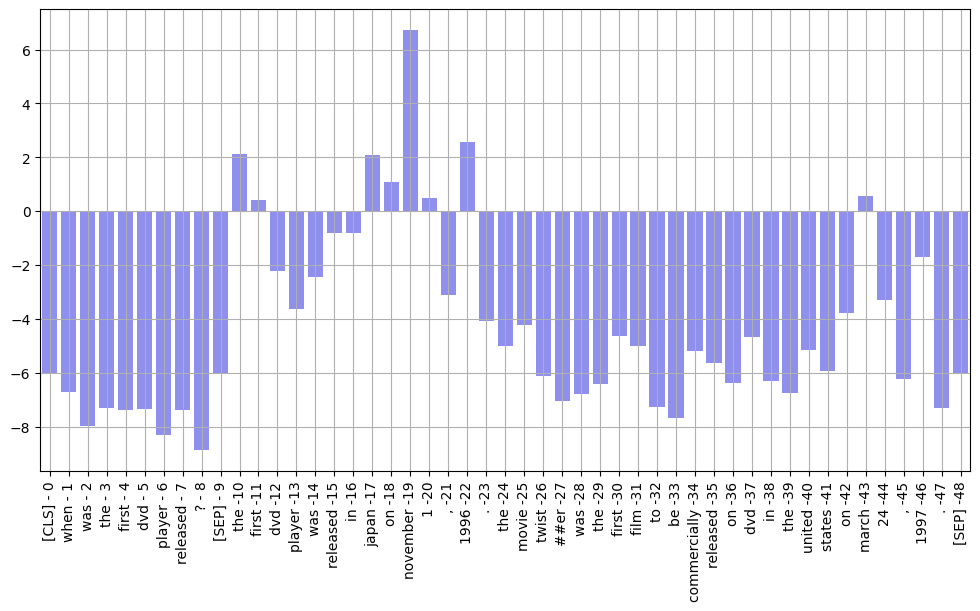

In [11]:
ax = sns.barplot(x=token_labels, y=s_scores, color="blue", alpha=0.5)
# set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()
ax.set_xticks(range(len(token_labels)))  # Set the x-ticks to match the number of token labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.figure.set_size_inches(12, 6)  # Enlarge the size of the figure to make it easier to read
ax.grid(True)

### Question Answering

In [1]:
from transformers import BertForQuestionAnswering, BertTokenizer
import torch


model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

model = BertForQuestionAnswering.from_pretrained(model_name) # 1.4GB
tokenizer = BertTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
sunset_motors_context = "Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar panels to power the facility, energy-efficient lighting, and a comprehensive recycling program. This commitment to eco-consciousness has earned Sunset Motors recognition as an industry leader in sustainable automotive retail. Sunset Motors proudly offers a diverse range of vehicles, including popular brands like Ford, Toyota, Honda, Chevrolet, and BMW, catering to a wide spectrum of tastes and preferences. In addition to its outstanding vehicle selection, Sunset Motors offers flexible financing options, allowing customers to secure affordable loans and leases with competitive interest rates."

def faq(question: str):
    """
    This function takes a question as input and returns an answer based on the context of Sunset Motors.
    """
    answer = ""
    input_ids = tokenizer.encode(question, sunset_motors_context)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    sep_idx = input_ids.index(tokenizer.sep_token_id)
    num_seg_a = sep_idx + 1
    num_seg_b = len(input_ids) - num_seg_a
    segment_ids = [0]*num_seg_a + [1]*num_seg_b
    output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))
    answer_start = torch.argmax(output.start_logits)
    answer_end = torch.argmax(output.end_logits)
    if answer_end >= answer_start:
        answer = tokens[answer_start:answer_end+1]
        answer = " ".join(word[2:] if word[0:2] == "##" else '' + word for word in answer)
    else:
        answer = "I don't know how to answer this question. You can try asking something else."
    return answer

faq("What is Sunset Motors")

'crest wood'

In [17]:
print(faq("Where's the dealship located?"))
print(faq("Give me a list of the available cars"))
print(faq("How large is the dealership"))

crest wood
popular brands like ford , toyota , honda , chevrolet , and bmw
over 10 acres


### Using RoBERTa and DistilBERT

In [ ]:
from transformers import RobertaTokenizer, RobertaModel
model_name = "roberta-base"  # https://huggingface.co/FacebookAI/roberta-base?show_file_info=model.safetensors
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
model_name = "distilbert-base-uncased"  # https://huggingface.co/distilbert/distilbert-base-uncased?show_file_info=model.safetensors
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name)